<a href="https://colab.research.google.com/github/abyansyah052/NLP-1/blob/main/Week2%263_Assignment/Tugas1A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## TUGAS 1A Scrapping Google Apps Review - BANK JAGO
Week 2 NLP Pipeline PBA/ Genap 2026/ Muhammad Abyansyah Putra Dewanto (5026231052)


In [3]:
!pip install google_play_scraper
!pip install textblob
!pip install seaborn
!pip install PySastrawi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 4.9 MB/s eta 0:00:00


In [19]:
from google_play_scraper import app, Sort, reviews_all
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.stem import WordNetLemmatizer # ubah ke kata dasar
from textblob import TextBlob
from collections import Counter # untuk hitung frekuensi list biasa kalau sklearn lebih kompleks

nltk.download('punkt') # buat tokenisasi
nltk.download('stopwords') # buat nyari stopword
nltk.download('punkt_tab')
nltk.download('wordnet') # buat ngunduh bank kata" untuk nanti lemmatization

%matplotlib inline
%config InlineBackend.figure_format='retina' #naikkan resolusi

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (15,10) # ngatur ukuran standar grafik

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [6]:
jago_reviews = reviews_all(
    'com.jago.digitalBanking',
    sleep_milliseconds = 10,
    lang = 'id',
    country = 'id',
    sort=Sort.NEWEST,
)

In [7]:
df_jagorev = pd.DataFrame(jago_reviews)

# milih kolom apa aja
df_jagorev = df_jagorev[["userName", "score", "at", "content"]]
# export ke csv
df_jagorev.to_csv('df_jagorev.csv', index=False)
print(f"scraped: {df_jagorev.shape}")
df_jagorev.head()


scraped: (68302, 4)


,userName,score,at,content
0,Pengguna Google,5,2026-03-30 17:20:34,aplinya baguz
1,Pengguna Google,5,2026-03-30 17:06:02,gokil
2,Pengguna Google,1,2026-03-30 17:03:43,bosok
3,Pengguna Google,1,2026-03-30 16:34:13,"nggak bisa login, tolong di fix lah, gw mau bu..."
4,Pengguna Google,1,2026-03-30 16:33:21,apk gk jlas


In [20]:
df_jagorev = pd.read_csv('df_jagorev.csv')
print(f"Loaded: {df_jagorev.shape}")
df_jagorev.head()

Loaded: (68302, 4)


,userName,score,at,content
0,Pengguna Google,5,2026-03-30 17:20:34,aplinya baguz
1,Pengguna Google,5,2026-03-30 17:06:02,gokil
2,Pengguna Google,1,2026-03-30 17:03:43,bosok
3,Pengguna Google,1,2026-03-30 16:34:13,"nggak bisa login, tolong di fix lah, gw mau bu..."
4,Pengguna Google,1,2026-03-30 16:33:21,apk gk jlas


score
5    42365
1    16587
4     3693
3     3084
2     2573
Name: count, dtype: int64


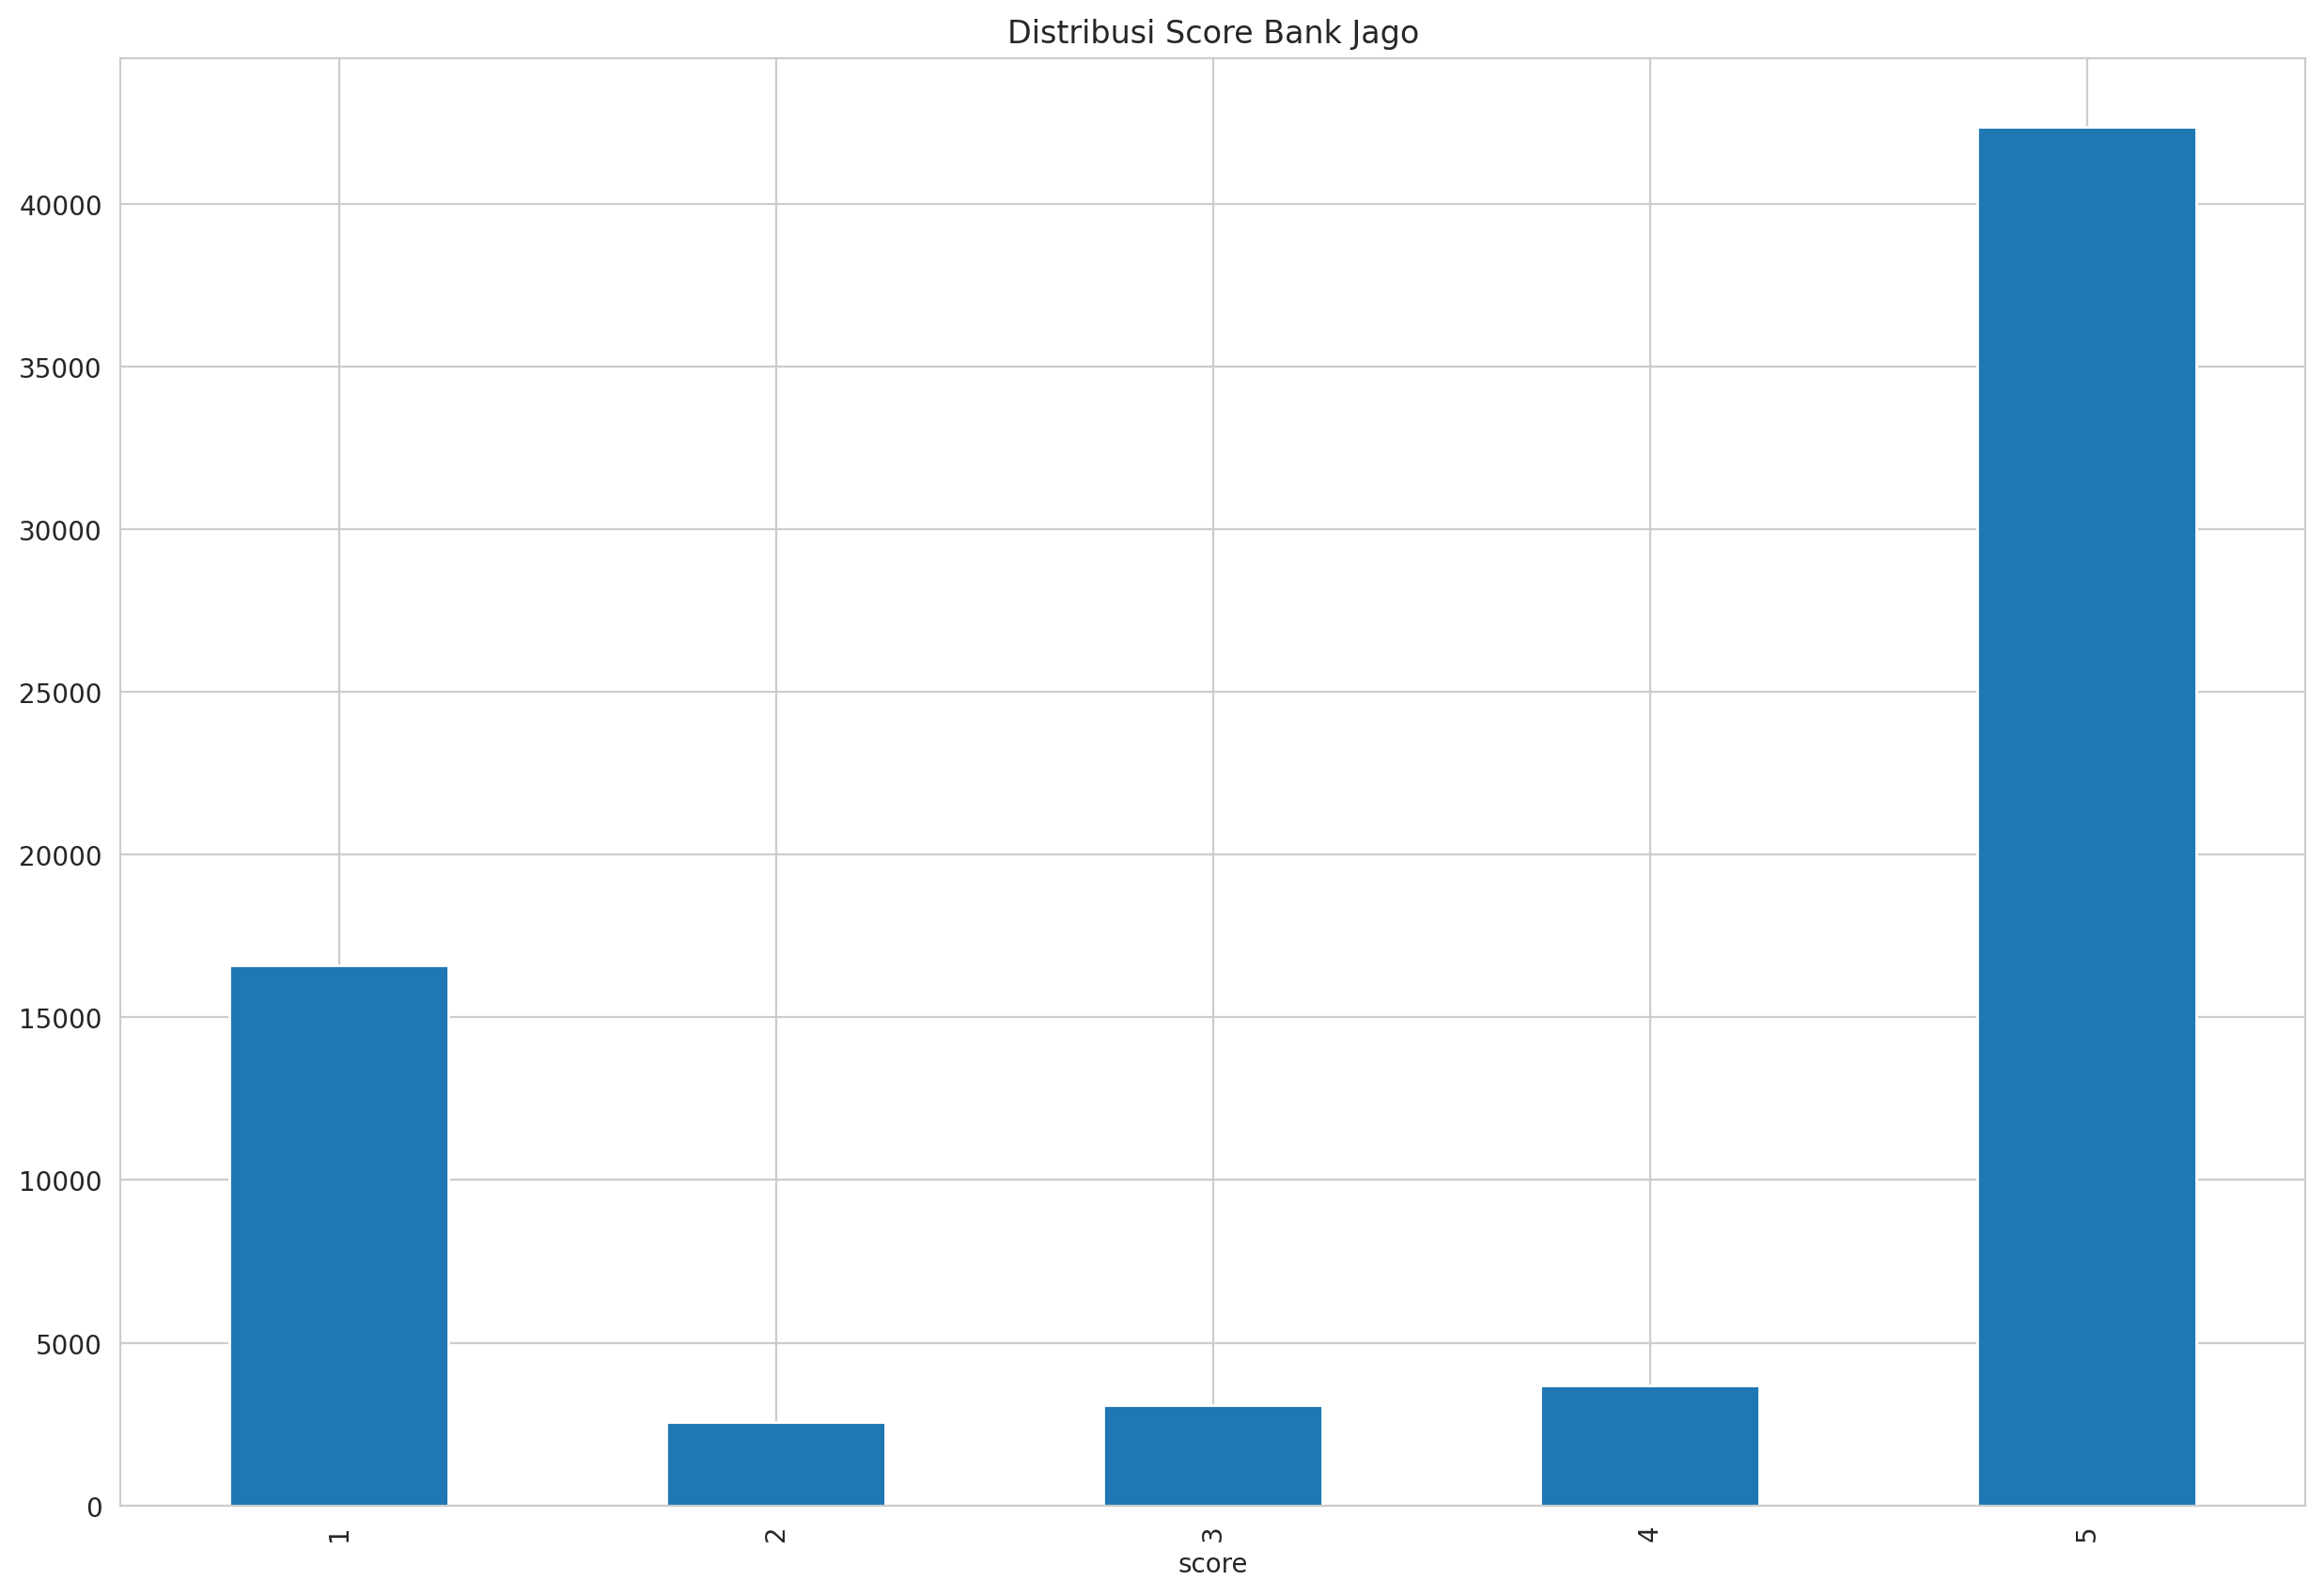

sentiment_rating
Positive    46058
Negative    19160
Neutral      3084
Name: count, dtype: int64


/tmp/ipykernel_5074/1465403139.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_5074/1465403139.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


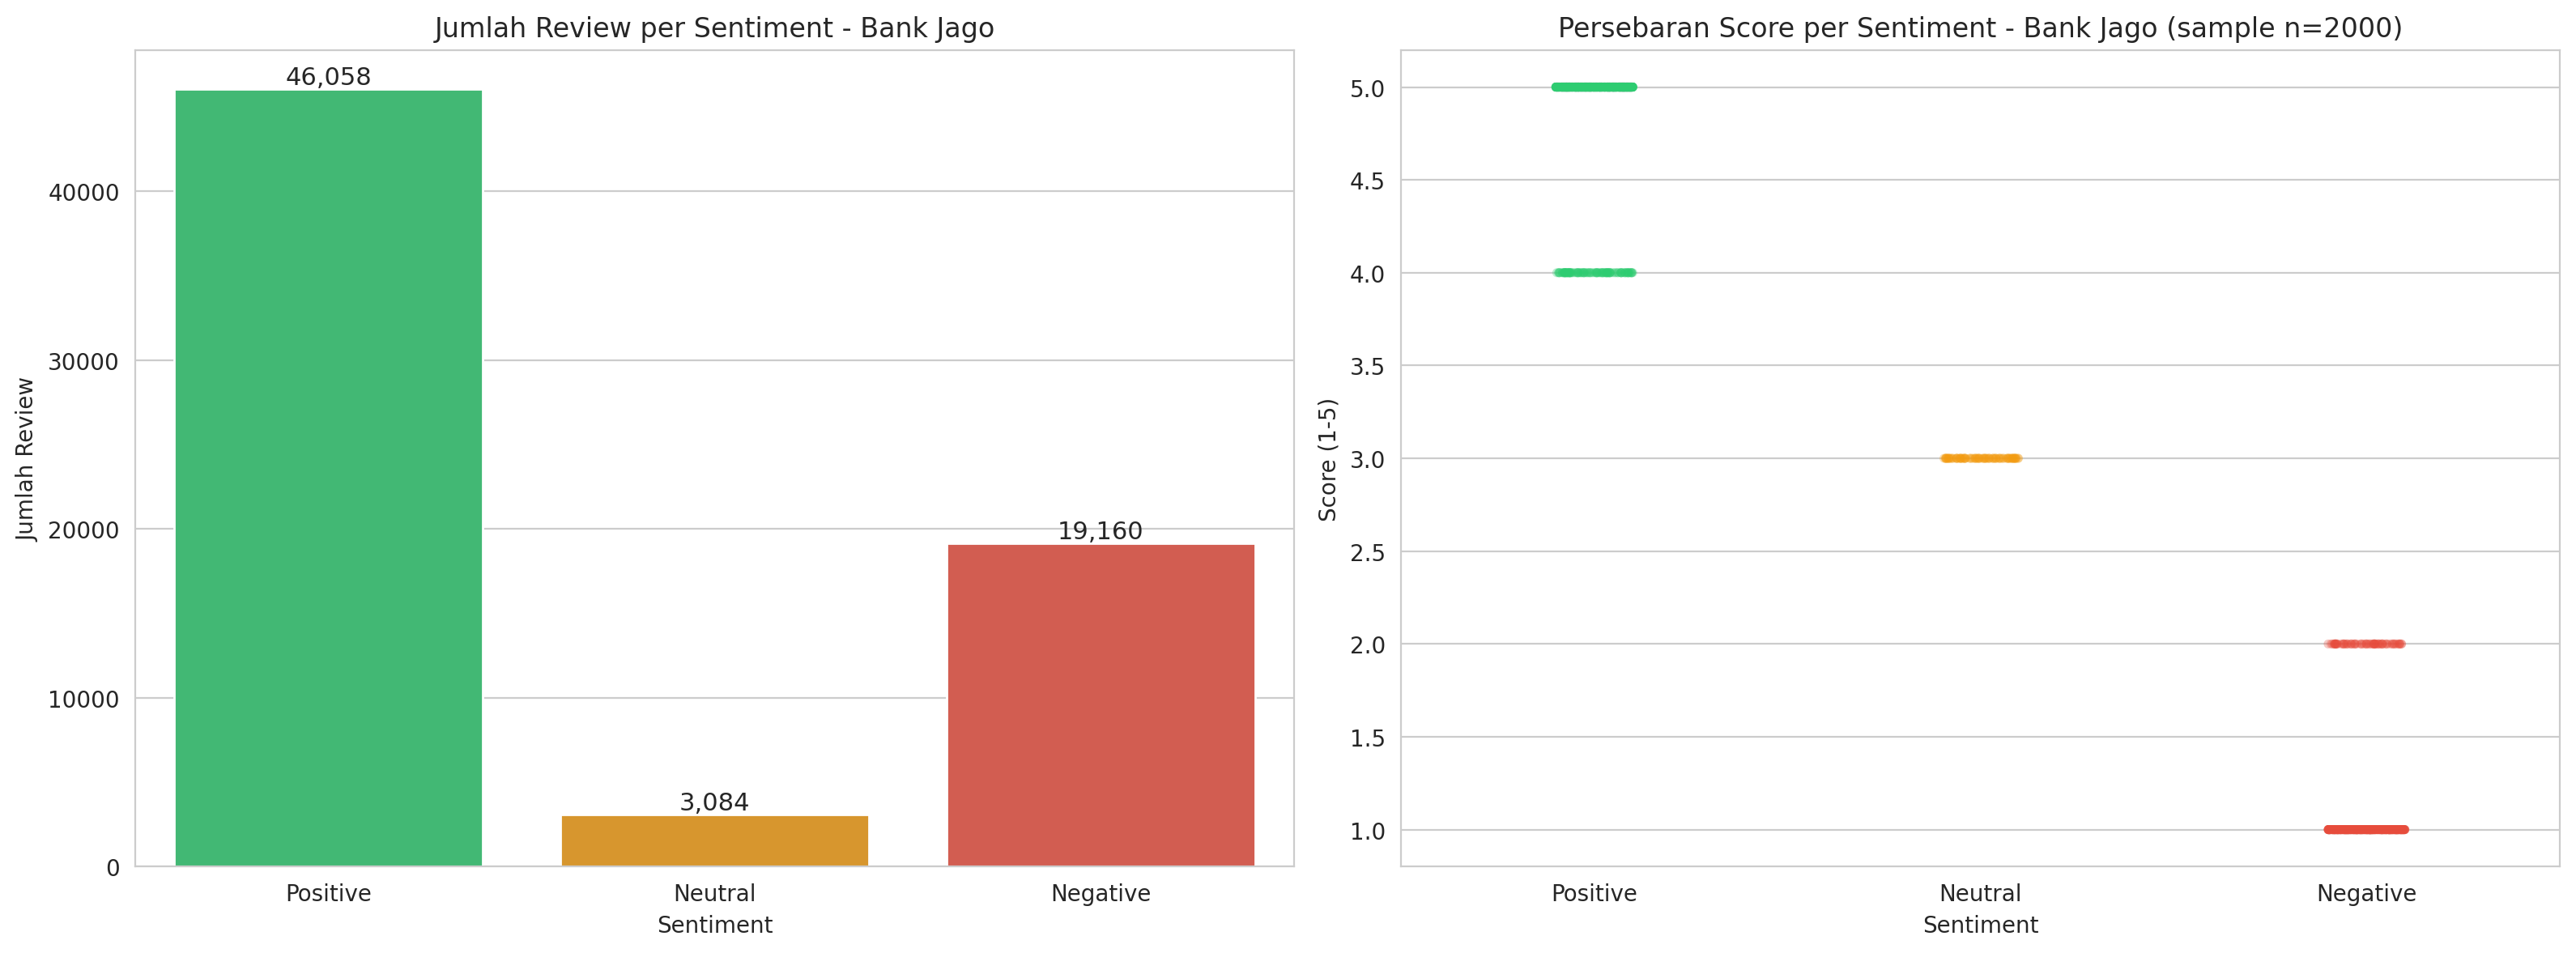

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,aplinya baguz,5,0.0,0.0,Positive
1,gokil,5,0.0,0.0,Positive
2,bosok,1,0.0,0.0,Negative
3,"nggak bisa login, tolong di fix lah, gw mau bu...",1,0.0,0.0,Negative
4,apk gk jlas,1,0.0,0.0,Negative


In [25]:
# Distribusi score
print(df_jagorev['score'].value_counts())
df_jagorev['score'].value_counts().sort_index().plot(kind='bar', title='Distribusi Score Bank Jago')
plt.show()

# TextBlob sentiment
df_jagorev['sentiment_polarity'] = df_jagorev['content'].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)
df_jagorev['sentiment_subjective'] = df_jagorev['content'].apply(
    lambda x: TextBlob(str(x)).sentiment.subjectivity
)

# Sentiment rating berdasarkan score
df_jagorev['sentiment_rating'] = df_jagorev['score'].apply(
    lambda x: 'Positive' if x > 3 else ('Negative' if x < 3 else 'Neutral')
)

# Visualisasi persebaran sentiment
print(df_jagorev['sentiment_rating'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(
    data=df_jagorev,
    x='sentiment_rating',
    order=['Positive', 'Neutral', 'Negative'],
    palette={'Positive': '#2ecc71', 'Neutral': '#f39c12', 'Negative': '#e74c3c'},
    ax=axes[0]
)
axes[0].set_title('Jumlah Review per Sentiment - Bank Jago')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Jumlah Review')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

sns.stripplot(
    data=df_jagorev.sample(2000, random_state=42),
    x='sentiment_rating',
    y='score',
    order=['Positive', 'Neutral', 'Negative'],
    palette={'Positive': '#2ecc71', 'Neutral': '#f39c12', 'Negative': '#e74c3c'},
    jitter=True,
    alpha=0.3,
    size=4,
    ax=axes[1]
)
axes[1].set_title('Persebaran Score per Sentiment - Bank Jago (sample n=2000)')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Score (1-5)')

plt.tight_layout()
plt.show()

df_jagorev[['content','score','sentiment_polarity','sentiment_subjective','sentiment_rating']].head()

In [37]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('indonesian'))

df_clean = df_jagorev[['content', 'score', 'sentiment_polarity',
                        'sentiment_subjective', 'sentiment_rating']].copy()
df_clean = df_clean.dropna(subset=['content']).reset_index(drop=True)

# lowering
df_clean['content'] = df_clean['content'].str.lower()
df_clean[['content', 'score', 'sentiment_rating']].head()

# buat slang
slang_dict = {
    'yg': 'yang', 'dgn': 'dengan', 'tdk': 'tidak', 'ga': 'tidak',
    'gak': 'tidak', 'gk': 'tidak', 'nggak': 'tidak', 'ngga': 'tidak',
    'udah': 'sudah', 'udh': 'sudah', 'sdh': 'sudah', 'dah': 'sudah',
    'blm': 'belum', 'blom': 'belum', 'emg': 'memang', 'emang': 'memang',
    'bgt': 'banget', 'bngt': 'banget', 'bs': 'bisa', 'jg': 'juga',
    'krn': 'karena', 'karna': 'karena', 'tp': 'tapi', 'tpi': 'tapi',
    'klo': 'kalau', 'klu': 'kalau', 'aja': 'saja', 'aj': 'saja',
    'ny': 'nya', 'sy': 'saya', 'lg': 'lagi', 'dr': 'dari',
    'utk': 'untuk', 'tyt': 'ternyata', 'msh': 'masih', 'sdg': 'sedang',
    'hrs': 'harus', 'dpt': 'dapat', 'jd': 'jadi', 'sm': 'sama',
}

def expand_contractions(text):
    words = text.split()
    return ' '.join([slang_dict.get(w, w) for w in words])

df_clean['content'] = df_clean['content'].apply(expand_contractions)
df_clean[['content', 'score']].head()

,content,score
0,aplinya baguz,5
1,gokil,5
2,bosok,1
3,"tidak bisa login, tolong di fix lah, gw mau bu...",1
4,apk tidak jlas,1


In [38]:
#  Punctuation Removal

df_clean['content'] = df_clean['content'].apply(
    lambda x: re.sub(r'[^a-zA-Z0-9\s]', ' ', str(x))
)
df_clean['content'] = df_clean['content'].apply(
    lambda x: re.sub(r'\s+', ' ', x).strip()
)
df_clean[['content', 'score']].head()

# Tokenization

df_clean['content'] = df_clean['content'].apply(
    lambda x: word_tokenize(str(x))
)
df_clean['content'].head()


# Stopword removal

print(f"Total NLTK Indonesian stopwords: {len(stop_words)}")

df_clean['content'] = df_clean['content'].apply(
    lambda tokens: [w for w in tokens if w not in stop_words and len(w) > 1]
)
df_clean['content'].head()


#Lemmatization

df_clean['content'] = df_clean['content'].apply(
    lambda tokens: [lemmatizer.lemmatize(w) for w in tokens]
)
df_clean['content'].head()

# stemming pake sastrawi
df_clean['content'] = df_clean['content'].apply(
    lambda tokens: [stemmer.stem(w) for w in tokens]
)
df_clean['content'].head()

Total NLTK Indonesian stopwords: 757


,content
0,"[aplinya, baguz]"
1,[gokil]
2,[bosok]
3,"[login, tolong, fix, gw, buka, anj]"
4,"[apk, jlas]"


In [39]:
def correct_spelling(tokens):
    return [re.sub(r'(.)\1{2,}', r'\1', w) for w in tokens]


In [40]:
all_words = [w for tokens in df_clean['content'] for w in tokens]
word_freq = Counter(all_words)

print(f"Total unique words: {len(word_freq)}\n")

print("Top 50 Frequent Words")
print(word_freq.most_common(50))

print("\nTop 100 Frequent Words")
print(word_freq.most_common(100))

print("\nTop 1000 Frequent Words")
print(word_freq.most_common(1000))

Total unique words: 21074

Top 50 Frequent Words
[('jago', 17918), ('bank', 12880), ('aplikasi', 10192), ('nya', 8993), ('bagus', 7226), ('mantap', 6264), ('mudah', 5008), ('akun', 4656), ('masuk', 4582), ('banget', 4231), ('bantu', 4185), ('login', 4148), ('transaksi', 4016), ('uang', 3917), ('saldo', 3311), ('daftar', 3109), ('tolong', 3032), ('apk', 2859), ('ya', 2644), ('transfer', 2468), ('kasih', 2464), ('hp', 2427), ('moga', 2394), ('ok', 2354), ('ribet', 2302), ('pakai', 2285), ('salah', 2267), ('pake', 2249), ('buka', 2186), ('data', 2166), ('email', 2128), ('baik', 2079), ('cepat', 1992), ('good', 1983), ('fitur', 1940), ('susah', 1896), ('verifikasi', 1824), ('coba', 1815), ('keren', 1789), ('bintang', 1752), ('gratis', 1749), ('aman', 1652), ('kartu', 1538), ('layan', 1518), ('kirim', 1505), ('pinjam', 1451), ('top', 1448), ('ganti', 1409), ('c', 1389), ('bayar', 1381)]

Top 100 Frequent Words
[('jago', 17918), ('bank', 12880), ('aplikasi', 10192), ('nya', 8993), ('bagus', 

/tmp/ipykernel_5074/1533672213.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top50, x='word', y='count', palette='Blues_r')


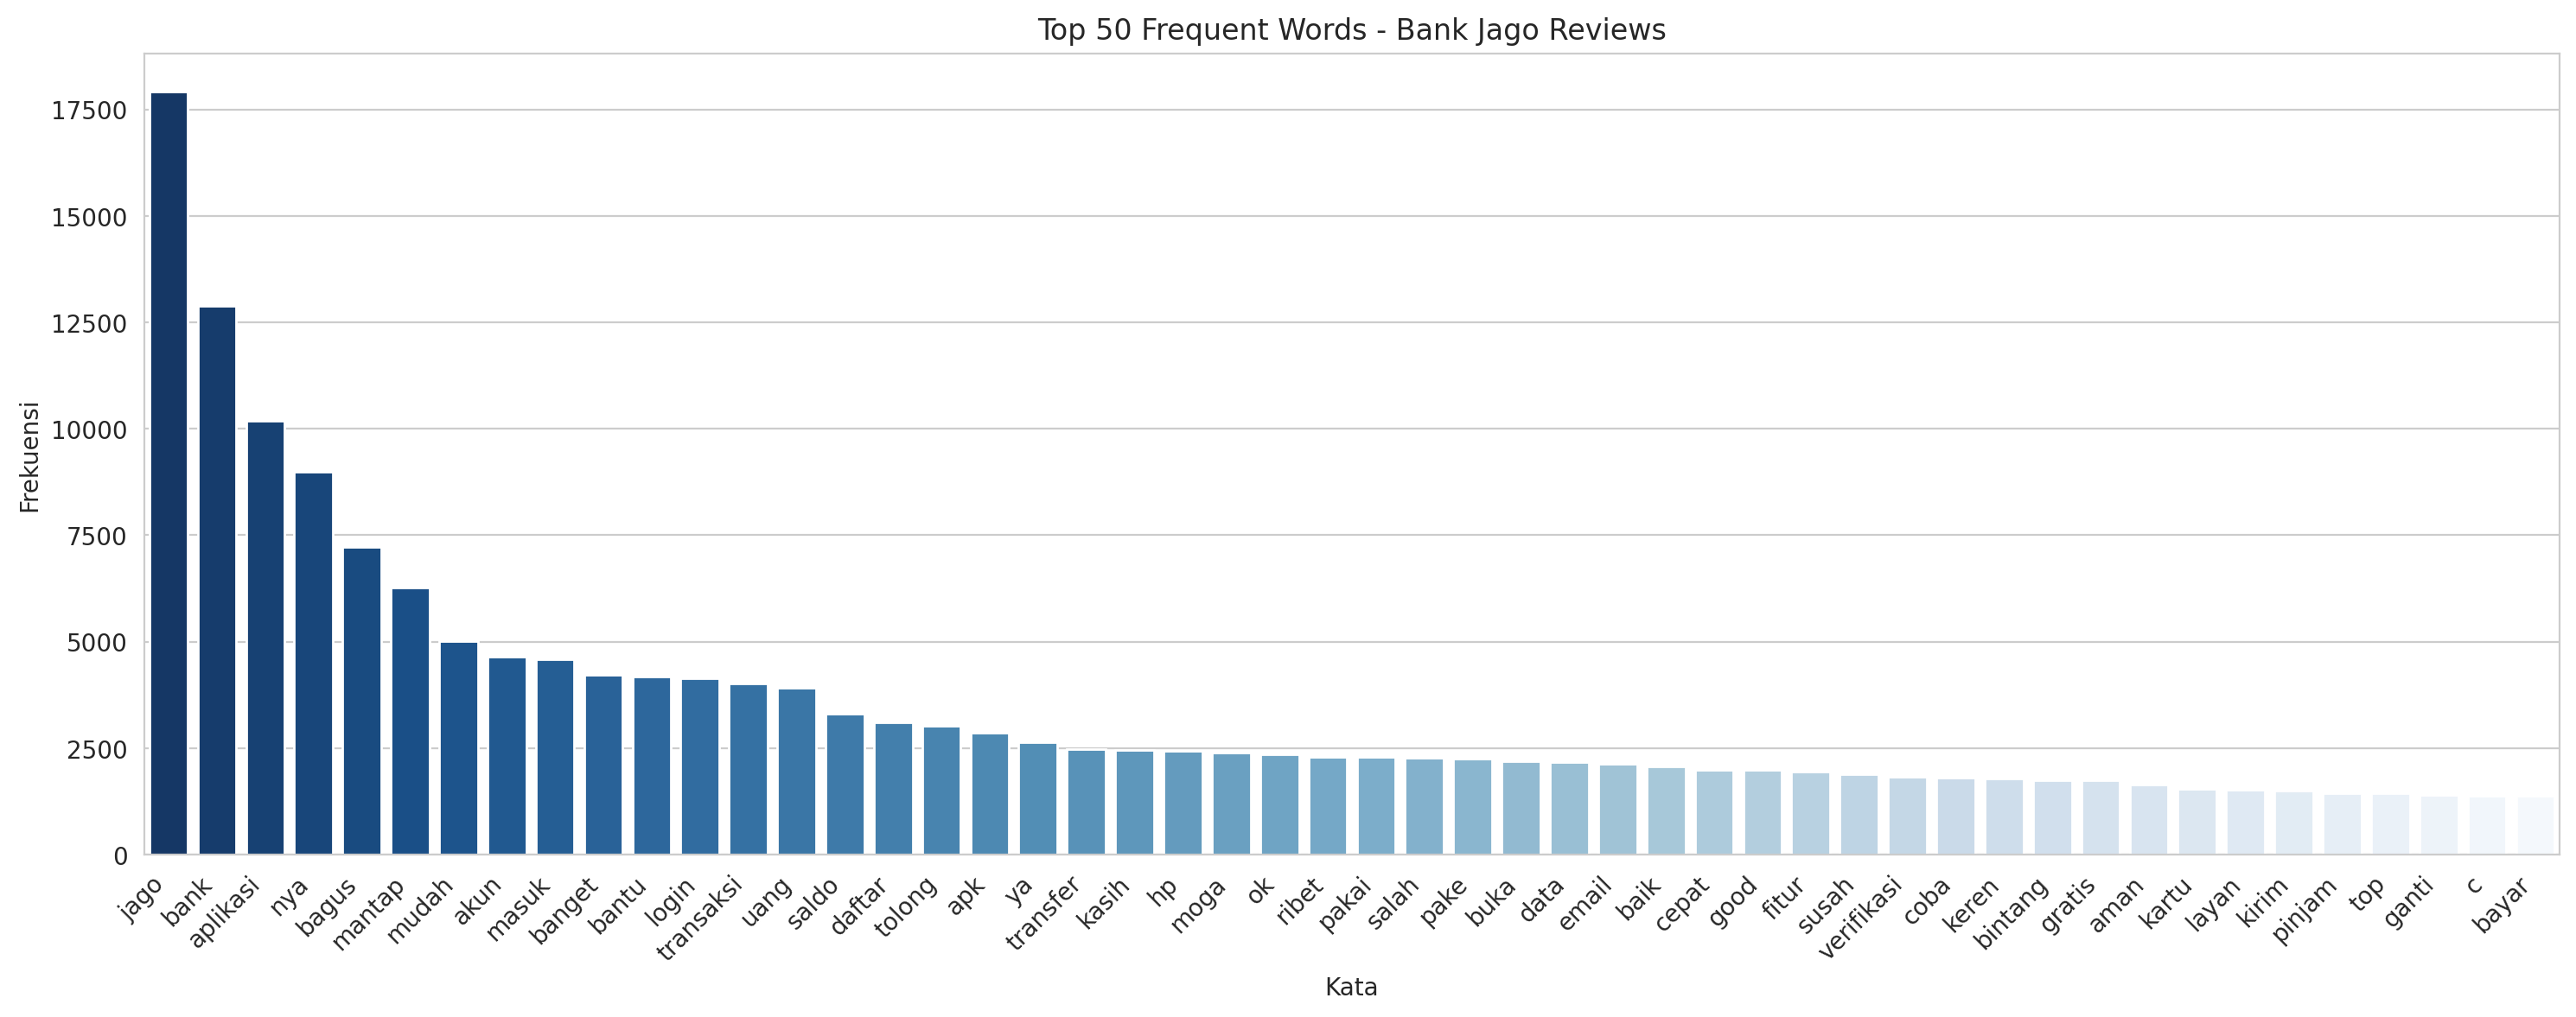

/tmp/ipykernel_5074/1533672213.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top100, x='word', y='count', palette='Greens_r')


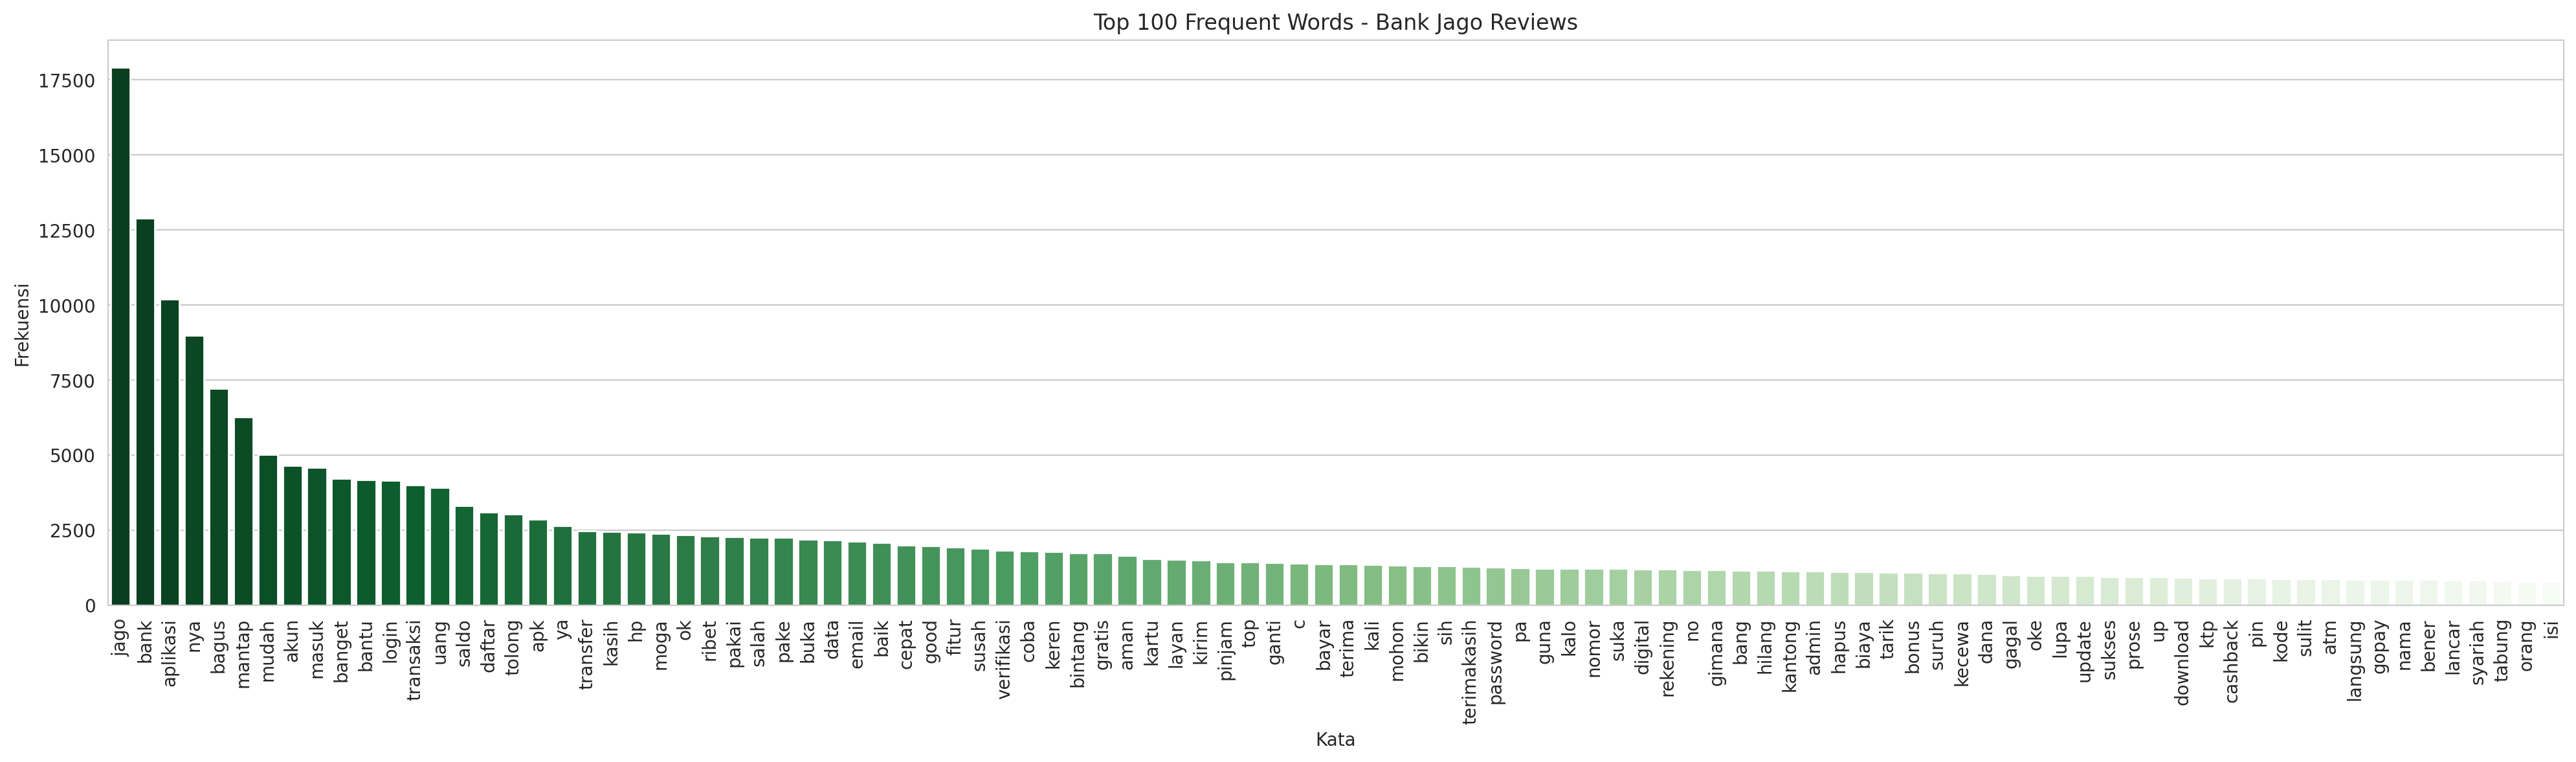

In [41]:
# Top 50
top50 = pd.DataFrame(word_freq.most_common(50), columns=['word', 'count'])
plt.figure(figsize=(15, 6))
sns.barplot(data=top50, x='word', y='count', palette='Blues_r')
plt.title('Top 50 Frequent Words - Bank Jago Reviews')
plt.xlabel('Kata')
plt.ylabel('Frekuensi')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Top 100
top100 = pd.DataFrame(word_freq.most_common(100), columns=['word', 'count'])
plt.figure(figsize=(20, 6))
sns.barplot(data=top100, x='word', y='count', palette='Greens_r')
plt.title('Top 100 Frequent Words - Bank Jago Reviews')
plt.xlabel('Kata')
plt.ylabel('Frekuensi')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [42]:
# Frequent Words found (new) dari hasil top 50/100 di atas

frequent_words_new = {
    # Nama produk
    'jago', 'bank', 'aplikasi', 'apk', 'app', 'bankjago', 'jagoo', 'jagooo',

    # Suffix / partikel / filler bahasa Indonesia
    'nya', 'ya', 'sih', 'nih', 'deh', 'ni', 'ko', 'aja', 'yah', 'yaa',
    'yaaa', 'iyaa', 'iya', 'deh', 'dong', 'tuh', 'kah', 'lah',

    # Kata ganti / sapaan
    'gw', 'gua', 'ku', 'lu', 'lo', 'sya', 'pa', 'bang', 'min', 'kak',
    'bg', 'ka', 'mas', 'mah', 'neng',

    # Singkatan noise yang lolos expand_contractions
    'pake', 'tf', 'sm', 'lg', 'tp', 'dg', 'jg', 'bgt', 'bngt', 'sgt',
    'tlg', 'tlong', 'tlp', 'tlpn', 'ksh', 'mksh', 'thx', 'tks', 'trima',
    'trimakasih', 'terimakasih', 'makasih', 'makas',

    # English noise words
    'the', 'is', 'it', 'in', 'so', 'by', 'and', 'to', 'up', 'no',
    'ok', 'oke', 'not', 'all', 'go', 'good', 'nice', 'bad', 'top',
    'best', 'fast', 'love', 'like', 'very', 'easy', 'real',

    # Filler pendek lainnya
    'c', 'moga', 'amin', 'aamiin', 'alhamdulillah', 'bismillah',
    'wkwk', 'wkwkwk', 'hehe', 'wow', 'ah', 'eh', 'aduh', 'dlu',
    'udah', 'dah', 'dh', 'uda', 'jdi', 'jd', 'tu', 'da', 'ga',
    'gak', 'gk', 'ngk', 'ngak', 'kaga', 'kagak', 'gada', 'gaada',
}


print("Frequent words found (new):", frequent_words_new)

stop_words.update(frequent_words_new)
print(f"\nTotal stopwords (NLTK + custom): {len(stop_words)}")

# Re-apply stopword removal
df_clean['content'] = df_clean['content'].apply(
    lambda tokens: [w for w in tokens if w not in stop_words and len(w) > 1]
)
df_clean['content'].head()

Frequent words found (new): {'ka', 'nya', 'love', 'mas', 'ga', 'gua', 'amin', 'sya', 'udah', 'top', 'sih', 'pa', 'bg', 'trima', 'best', 'thx', 'bgt', 'is', 'go', 'gk', 'ya', 'deh', 'ah', 'ok', 'ko', 'sgt', 'oke', 'uda', 'dg', 'not', 'wkwkwk', 'lo', 'dh', 'kak', 'easy', 'ngak', 'kah', 'app', 'nice', 'min', 'tuh', 'tlong', 'like', 'gak', 'iya', 'mksh', 'lg', 'it', 'tf', 'terimakasih', 'dah', 'bad', 'very', 'kagak', 'jagoo', 'yaaa', 'tlg', 'bank', 'c', 'ku', 'kaga', 'moga', 'tp', 'real', 'good', 'hehe', 'ksh', 'and', 'eh', 'aja', 'neng', 'all', 'aamiin', 'trimakasih', 'makas', 'iyaa', 'aplikasi', 'the', 'gw', 'tu', 'apk', 'jd', 'up', 'aduh', 'fast', 'makasih', 'tks', 'mah', 'yah', 'dong', 'jg', 'ni', 'da', 'in', 'wow', 'jdi', 'jago', 'jagooo', 'gaada', 'nih', 'wkwk', 'yaa', 'bang', 'bismillah', 'pake', 'tlpn', 'alhamdulillah', 'gada', 'so', 'bankjago', 'sm', 'to', 'ngk', 'lah', 'tlp', 'bngt', 'by', 'dlu', 'lu', 'no'}

Total stopwords (NLTK + custom): 875


,content
0,"[aplinya, baguz]"
1,[gokil]
2,[bosok]
3,"[login, tolong, fix, buka, anj]"
4,[jlas]


In [43]:
#Rare Words Removal

all_words2 = [w for tokens in df_clean['content'] for w in tokens]
word_freq2 = Counter(all_words2)

rare_words = {w for w, c in word_freq2.items() if c < 3}
print(f"Rare words removed: {len(rare_words)}")

df_clean['content'] = df_clean['content'].apply(
    lambda tokens: [w for w in tokens if w not in rare_words]
)
df_clean['content'].head()

Rare words removed: 15076


,content
0,[baguz]
1,[gokil]
2,[bosok]
3,"[login, tolong, fix, buka, anj]"
4,[jlas]


In [44]:
#common words removal

total_docs = len(df_clean)
common_words = {w for w, c in word_freq2.items() if c > total_docs * 0.8}
print(f"Common words removed: {len(common_words)}")
if common_words:
    print(f"Common words: {common_words}")

df_clean['content'] = df_clean['content'].apply(
    lambda tokens: [w for w in tokens if w not in common_words]
)
df_clean['content'].head()

Common words removed: 0


,content
0,[baguz]
1,[gokil]
2,[bosok]
3,"[login, tolong, fix, buka, anj]"
4,[jlas]


In [45]:
#Join Token & Save cleandata.csv

df_clean['content'] = df_clean['content'].apply(lambda tokens: ' '.join(tokens))

df_clean = df_clean[df_clean['content'].str.strip() != ''].reset_index(drop=True)

df_clean.to_csv('cleandata.csv', index=False)

print(f"Raw data  : {df_jagorev.shape[0]} rows")
print(f"Clean data: {df_clean.shape[0]} rows")
print(f"Rows removed: {df_jagorev.shape[0] - df_clean.shape[0]}")
print("cleandata.csv berhasil disimpan!")

df_clean


Raw data  : 68302 rows
Clean data: 59965 rows
Rows removed: 8337
cleandata.csv berhasil disimpan!


,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,baguz,5,0.0,0.000000,Positive
1,gokil,5,0.0,0.000000,Positive
2,bosok,1,0.0,0.000000,Negative
3,login tolong fix buka anj,1,0.0,0.000000,Negative
4,jlas,1,0.0,0.000000,Negative
...,...,...,...,...,...
59960,digibank simple amazing hati rakyat goooo,5,0.3,0.628571,Positive
59961,mantap suka ui fresh banget,5,0.3,0.500000,Positive
59962,sesuai nama kecewa,5,0.0,0.000000,Positive
59963,mantab,5,0.0,0.000000,Positive
